# SEC 10-K RAG Pipeline
**STAT 453 — Group 17**

This notebook runs the full pipeline end-to-end:
1. **Ingestion** — fetch 10-K filings from SEC EDGAR, parse sections, chunk text
2. **Indexing** — embed chunks and store in ChromaDB (local, free)
3. **Retrieval + Generation** — retrieve relevant chunks and generate grounded answers with Ollama

No API keys required — everything runs locally on your machine.

## 0. Setup

In [1]:
# Install dependencies (only needed once)
import sys
!{sys.executable} -m pip install requests beautifulsoup4 lxml tiktoken tqdm chromadb sentence-transformers ollama -q
print("Dependencies ready.")

Dependencies ready.


In [2]:
import os
import logging

# Point imports at the project root (works whether notebook is in project/ or a subdir)
PROJECT_ROOT = os.path.dirname(os.path.abspath("__file__"))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Set up clean logging
logging.basicConfig(
    format="%(asctime)s  %(levelname)-8s  %(name)s — %(message)s",
    datefmt="%H:%M:%S",
    level=logging.INFO,
)
for noisy in ["urllib3", "requests", "httpx", "openai", "chromadb", "sentence_transformers"]:
    logging.getLogger(noisy).setLevel(logging.WARNING)

print("Project root:", PROJECT_ROOT)

Project root: /Users/ariffdziqri/Desktop/STAT453/project


---
## 1. Ingestion — Fetch & Parse 10-K Filings

In [3]:
from config import COMPANIES, FILING_YEARS, TARGET_SECTIONS

print("Companies:", list(COMPANIES.keys()))
print("Years:", FILING_YEARS)
print("Sections:", list(TARGET_SECTIONS.values()))

Companies: ['AAPL', 'MSFT', 'GOOGL', 'NVDA', 'TSLA', 'AMZN', 'META', 'JNJ', 'XOM', 'PG']
Years: [2022, 2023, 2024]
Sections: ['Business', 'Risk Factors', 'Management Discussion and Analysis', 'Quantitative and Qualitative Disclosures About Market Risk', 'Financial Statements']


In [4]:
# --- Fetch: resolve ticker → CIK → find 10-K filing → download HTML ---
from ingestion.edgar_fetcher import fetch_ticker

# Start with one company and one year (fast)
TICKER = "TSLA"
YEAR   = 2023

records = fetch_ticker(TICKER, years=[YEAR])

for r in records:
    print(f"Ticker:     {r['ticker']}")
    print(f"CIK:        {r['cik']}")
    print(f"Filed:      {r['filing_date']}")
    print(f"Accession:  {r['accession_number']}")
    print(f"Saved to:   {r['local_path']}")

15:20:41  INFO      ingestion.edgar_fetcher — Already downloaded: TSLA_2023_000095017023001409.htm


Ticker:     TSLA
CIK:        0001318605
Filed:      2023-01-31
Accession:  0000950170-23-001409
Saved to:   /Users/ariffdziqri/Desktop/STAT453/project/data/raw/TSLA_2023_000095017023001409.htm


In [5]:
# --- Parse: extract named sections from the HTML ---
from ingestion.section_parser import parse_file

local_path = records[0]["local_path"]
sections   = parse_file(local_path)

print(f"Sections extracted: {list(sections.keys())}\n")
for key, text in sections.items():
    print(f"  {key:10}  {len(text):>8,} chars  |  {text[:80]!r}")

15:20:45  INFO      ingestion.section_parser — Extracted item_1: 42165 chars
15:20:45  INFO      ingestion.section_parser — Extracted item_1a: 82556 chars
15:20:45  INFO      ingestion.section_parser — Extracted item_7: 56318 chars
15:20:45  INFO      ingestion.section_parser — Extracted item_7a: 1692 chars
15:20:45  INFO      ingestion.section_parser — Extracted item_8: 174627 chars


Sections extracted: ['item_1', 'item_1a', 'item_7', 'item_7a', 'item_8']

  item_1        42,165 chars  |  'ITEM 1. BUSINESS Overview We design, develop, manufacture, sell and lease high-p'
  item_1a       82,556 chars  |  'ITEM 1A. RISK FACTORS You should carefully consider the risks described below to'
  item_7        56,318 chars  |  'ITEM 7. MANAGEMENT’S DISCUSSION AND ANALYSIS OF FINANCIAL CONDITION AND RESULTS '
  item_7a        1,692 chars  |  'QUANTITATIVE AND QUALITATIVE DISCLOSURES ABOUT MARKET RISK Foreign Currency Risk'
  item_8       174,627 chars  |  'ITEM 8. FINANCIAL STATEMENTS AND SUPPLEMENTARY DATA Index to Consolidated Financ'


In [6]:
# --- Chunk: split sections into ~500 token pieces ---
from ingestion.chunker import chunk_filing

chunks = chunk_filing(
    sections,
    ticker = records[0]["ticker"],
    cik    = records[0]["cik"],
    year   = records[0]["year"],
)

print(f"Total chunks: {len(chunks)}")
print(f"Token range:  {min(c['token_count'] for c in chunks)} – {max(c['token_count'] for c in chunks)}")
print(f"Avg tokens:   {sum(c['token_count'] for c in chunks) / len(chunks):.1f}")

15:20:52  INFO      ingestion.chunker — TSLA 2023 | item_1 → 16 chunks (avg 485 tokens)
15:20:52  INFO      ingestion.chunker — TSLA 2023 | item_1a → 33 chunks (avg 464 tokens)
15:20:52  INFO      ingestion.chunker — TSLA 2023 | item_7 → 26 chunks (avg 454 tokens)
15:20:52  INFO      ingestion.chunker — TSLA 2023 | item_7a → 1 chunks (avg 324 tokens)
15:20:52  INFO      ingestion.chunker — TSLA 2023 | item_8 → 100 chunks (avg 396 tokens)


Total chunks: 176
Token range:  29 – 518
Avg tokens:   424.8


In [7]:
# --- Preview a chunk ---
import json

sample = next(c for c in chunks if c["section_key"] == "item_1a")
print(json.dumps({k: v for k, v in sample.items() if k != "text"}, indent=2))
print("\nText preview:")
print(sample["text"][:400])

{
  "ticker": "TSLA",
  "cik": "0001318605",
  "year": 2023,
  "section_key": "item_1a",
  "section_label": "Risk Factors",
  "chunk_index": 0,
  "total_chunks": 33,
  "token_count": 488
}

Text preview:
ITEM 1A. RISK FACTORS You should carefully consider the risks described below together with the other information set forth in this report, which could materially affect our business, financial condition and future results. The risks described below are not the only risks facing our company. Risks and uncertainties not currently known to us or that we currently deem to be immaterial also may mater


In [8]:
# --- Run full ingestion for multiple tickers (saves to data/chunks/*.jsonl) ---
from ingestion.pipeline import run as run_ingestion

# Change tickers/years as needed
run_ingestion(tickers=["TSLA", "AAPL"], years=[2023])

Tickers × Years:   0%|                                | 0/2 [00:00<?, ?filing/s]15:20:59  INFO      ingestion.pipeline — ─── TSLA  2023 ────────────────────────────────
15:21:00  INFO      ingestion.edgar_fetcher — Already downloaded: TSLA_2023_000095017023001409.htm
15:21:00  INFO      ingestion.pipeline — Parsing TSLA 2023…
15:21:00  INFO      ingestion.section_parser — Extracted item_1: 42165 chars
15:21:00  INFO      ingestion.section_parser — Extracted item_1a: 82556 chars
15:21:00  INFO      ingestion.section_parser — Extracted item_7: 56318 chars
15:21:00  INFO      ingestion.section_parser — Extracted item_7a: 1692 chars
15:21:00  INFO      ingestion.section_parser — Extracted item_8: 174627 chars
15:21:00  INFO      ingestion.chunker — TSLA 2023 | item_1 → 16 chunks (avg 485 tokens)
15:21:01  INFO      ingestion.chunker — TSLA 2023 | item_1a → 33 chunks (avg 464 tokens)
15:21:01  INFO      ingestion.chunker — TSLA 2023 | item_7 → 26 chunks (avg 454 tokens)
15:21:01  INFO      


  Ingestion complete: 261 chunks  |  110,302 tokens

Chunks per ticker:
  AAPL         85
  TSLA        176

Chunks per section:
  Financial Statements                             142
  Risk Factors                                      59
  Management Discussion and Analysis                35
  Business                                          22
  Quantitative and Qualitative Disclosures About Market Risk      3



[{'text': 'ITEM 1. BUSINESS Overview We design, develop, manufacture, sell and lease high-performance fully electric vehicles and energy generation and storage systems, and offer services related to our products. We generally sell our products directly to customers, and continue to grow our customer-facing infrastructure through a global network of vehicle service centers, Mobile Service, body shops, Supercharger stations and Destination Chargers to accelerate the widespread adoption of our products. We emphasize performance, attractive styling and the safety of our users and workforce in the design and manufacture of our products and are continuing to develop full self-driving technology for improved safety. We also strive to lower the cost of ownership for our customers through continuous efforts to reduce manufacturing costs and by offering financial and other services tailored to our products. Our mission is to accelerate the world’s transition to sustainable energy. We believe tha

---
## 2. EDA — Explore the Chunk Dataset

In [9]:
import glob
import pandas as pd

files   = glob.glob("data/chunks/*.jsonl")
records = []
for f in files:
    with open(f) as fh:
        for line in fh:
            records.append(json.loads(line))

df = pd.DataFrame(records)
print(f"Shape: {df.shape}")
df.head(3)

Shape: (3904, 9)


,text,ticker,cik,year,section_key,section_label,chunk_index,total_chunks,token_count
0,Item 1. Business. The Procter & Gamble Company...,PG,0000080424,2023,item_1,Business,0,6,491
1,Our growth strategy is to deliver meaningful a...,PG,0000080424,2023,item_1,Business,1,6,489
2,Trademarks and Patents . We own or have licens...,PG,0000080424,2023,item_1,Business,2,6,497


In [10]:
# Chunks per ticker × section
df.pivot_table(
    index="ticker",
    columns="section_label",
    values="chunk_index",
    aggfunc="count",
    fill_value=0,
)

section_label,Business,Financial Statements,Management Discussion and Analysis,Quantitative and Qualitative Disclosures About Market Risk,Risk Factors
ticker,,,,,
AAPL,18,130,28,7,79
AMZN,18,211,67,14,74
GOOGL,36,221,78,13,91
JNJ,48,438,118,3,50
META,40,188,106,8,238
MSFT,31,70,75,144,27
NVDA,65,3,57,6,108
PG,17,211,140,3,45
TSLA,54,190,76,107,99


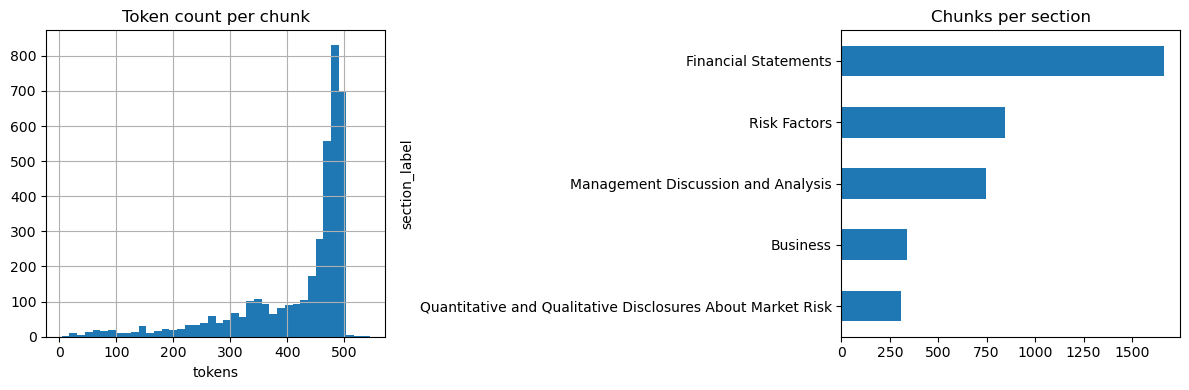

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Token distribution
df["token_count"].hist(bins=40, ax=axes[0])
axes[0].set_title("Token count per chunk")
axes[0].set_xlabel("tokens")

# Chunks per section
df.groupby("section_label").size().sort_values().plot.barh(ax=axes[1])
axes[1].set_title("Chunks per section")

plt.tight_layout()
plt.show()

---
## 3. Indexing — Embed Chunks and Store in ChromaDB

In [12]:
# --- Embed chunks (local model, no API key needed) ---
from indexing.index_pipeline import run as run_indexing

run_indexing(
    tickers = ["TSLA", "AAPL"],
    years   = [2023],
    backend = "local",   # switch to "openai" when you have a key
    reset   = False,     # set True to wipe and re-index from scratch
)

15:21:21  INFO      indexing.index_pipeline — Loading chunks for tickers=['TSLA', 'AAPL'] years=[2023]
15:21:21  INFO      indexing.index_pipeline — Loaded 85 chunks from AAPL_2023.jsonl
15:21:21  INFO      indexing.index_pipeline — Loaded 176 chunks from TSLA_2023.jsonl
15:21:21  INFO      indexing.index_pipeline — Total chunks loaded: 261
15:21:22  INFO      indexing.vector_store — Collection 'sec_10k_filings' ready — 3904 documents currently indexed
15:21:22  INFO      indexing.index_pipeline — Skipping 261 already-indexed chunks (0 new to embed)
15:21:22  INFO      indexing.index_pipeline — All chunks already indexed. Nothing to do.



  ChromaDB collection: 'sec_10k_filings'
  Total vectors indexed: 3,904
  Tickers:  AAPL, AMZN, GOOGL, JNJ, META, MSFT, NVDA, PG, TSLA, XOM
  Years:    2022, 2023, 2024
  Sections: 5



In [13]:
# --- Inspect the ChromaDB collection ---
from indexing.vector_store import get_collection, collection_stats

col   = get_collection()
stats = collection_stats(col)

print(f"Total vectors : {stats['total_chunks']:,}")
print(f"Tickers       : {stats['tickers']}")
print(f"Years         : {stats['years']}")
print(f"Sections      : {stats['sections']}")

15:21:24  INFO      indexing.vector_store — Collection 'sec_10k_filings' ready — 3904 documents currently indexed


Total vectors : 3,904
Tickers       : ['AAPL', 'AMZN', 'GOOGL', 'JNJ', 'META', 'MSFT', 'NVDA', 'PG', 'TSLA', 'XOM']
Years         : [2022, 2023, 2024]
Sections      : ['Business', 'Financial Statements', 'Management Discussion and Analysis', 'Quantitative and Qualitative Disclosures About Market Risk', 'Risk Factors']


---
## 4. Retrieval — Similarity Search

In [14]:
from generation.retriever import retrieve, format_context

QUERY = "What are Tesla's main risk factors?"

results = retrieve(
    QUERY,
    top_k   = 5,
    filters = {"ticker": "TSLA"},  # optional: narrow to one company
    backend = "local",
)

print(f"Top {len(results)} results for: '{QUERY}'\n")
for i, r in enumerate(results, 1):
    print(f"[{i}] {r['ticker']} {r['year']} | {r['section_label']} | "
          f"chunk {r['chunk_index']}  (distance: {r['distance']:.4f})")
    print(f"     {r['text'][:150]}…")
    print()

15:21:28  INFO      generation.retriever — Retrieving top-5 chunks for: "What are Tesla's main risk factors?"
15:21:28  INFO      indexing.embedder — Backend: local sentence-transformers/all-MiniLM-L6-v2 (1 texts)
15:21:31  INFO      indexing.embedder — Loading local embedding model 'sentence-transformers/all-MiniLM-L6-v2' (first run downloads ~90MB)…
15:21:31  WARNING   huggingface_hub.utils._http — Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
15:21:33  INFO      indexing.embedder — Local model loaded.
15:21:33  INFO      indexing.vector_store — Collection 'sec_10k_filings' ready — 3904 documents currently indexed
15:21:33  INFO      generation.retriever — Retrieved 5 chunks (best distance: 0.4663)


Top 5 results for: 'What are Tesla's main risk factors?'

[1] TSLA 2023 | Financial Statements | chunk 19  (distance: 0.4663)
     Notes to Consolidated Financial Statements Note 1 – Overview Tesla, Inc. (“Tesla”, the “Company”, “we”, “us” or “our”) was incorporated in the State o…

[2] TSLA 2023 | Risk Factors | chunk 7  (distance: 0.4861)
     Our future growth and success are dependent upon consumers’ demand for electric vehicles and specifically our vehicles in an automotive industry that …

[3] TSLA 2022 | Risk Factors | chunk 4  (distance: 0.4928)
     Our future growth and success are dependent upon consumers’ demand for electric vehicles and specifically our vehicles in an automotive industry that …

[4] TSLA 2022 | Quantitative and Qualitative Disclosures About Market Risk | chunk 18  (distance: 0.4936)
     N otes to Consolidated Financial Statements Note 1 – Overview Tesla, Inc. (“Tesla”, the “Company”, “we”, “us” or “our”) was incorporated in the State …

[5] TSLA 2022 | Bu

---
## 5. Generation — Answer with Citations (Ollama)

In [15]:
# Make sure Ollama is running
import subprocess
result = subprocess.run(["ollama", "list"], capture_output=True, text=True)
print(result.stdout if result.returncode == 0 else "Ollama not running — run: brew services start ollama")

NAME           ID              SIZE      MODIFIED      
llama3.2:3b    a80c4f17acd5    2.0 GB    8 minutes ago    



In [16]:
from generation.generator import generate

context = format_context(results)   # from the retrieval cell above

answer = generate(
    question    = QUERY,
    context     = context,
    model       = "llama3.2:3b",
    stream      = False,    # set True to stream tokens as they arrive
    temperature = 0.1,
)

print("Answer:\n")
print(answer)
print("\nSources:")
for i, r in enumerate(results, 1):
    print(f"  [{i}] {r['ticker']} {r['year']} | {r['section_label']} | chunk {r['chunk_index']}")

15:21:42  INFO      generation.generator — Generating answer with llama3.2:3b (stream=False)…


Answer:

According to the provided context passages, Tesla's main risk factors include:

* Dependence on consumers' demand for electric vehicles and the automotive industry being competitive, cyclical, and volatile (passages [2] and [3])
* Competition from other types of alternative fuel vehicles, plug-in hybrid electric vehicles, and high fuel-economy internal combustion engine vehicles (passage [2])
* Perceptions about electric vehicle features, quality, safety, performance, and cost (passage [2])
* Limited range over which electric vehicles may be driven on a single battery charge, and access to charging facilities (passage [2])
* Volatility in the cost of oil, gasoline, and energy (passage [3])
* Government regulations and economic incentives (passage [3])
* Concerns about future viability (passage [2])
* Supply chain disruptions, including component shortages and supplier failures (passages [3] and [5])
* Environmental factors such as natural disasters, health epidemics, trade pol

---
## 6. Full RAG Pipeline — One Function

In [17]:
from generation.rag_pipeline import ask

# Try the example queries from the proposal
response = ask(
    question = "What are Tesla's top risk factors this year?",
    ticker   = "TSLA",
    year     = 2023,
    top_k    = 5,
    model    = "llama3.2:3b",
    backend  = "local",
    stream   = False,
)

print(response["answer"])

15:22:05  INFO      generation.retriever — Retrieving top-5 chunks for: "What are Tesla's top risk factors this year?"
15:22:05  INFO      indexing.embedder — Backend: local sentence-transformers/all-MiniLM-L6-v2 (1 texts)
15:22:05  INFO      indexing.vector_store — Collection 'sec_10k_filings' ready — 3904 documents currently indexed
15:22:05  INFO      generation.retriever — Retrieved 5 chunks (best distance: 0.4063)
15:22:05  INFO      generation.generator — Generating answer with llama3.2:3b (stream=False)…



Answer:
According to the provided context passages, Tesla's top risk factors for this year include:

1. Dependence on consumers' demand for electric vehicles and specific market conditions in an automotive industry that is generally competitive, cyclical, and volatile. (Source: [2])
2. Competition from established and new competitors in the automotive market, including those offering or planning to offer electric vehicles exclusively. (Source: [2])
3. Dependence on the services of Elon Musk, Technoking of Tesla, and other key employees, as well as their ability to attract and retain senior leadership necessary for business growth. (Sources: [3], [4])
4. Impact of inflationary pressures, rising energy prices, increases in interest rates, and global economic conditions on vehicle pricing and demand. (Source: [4])
5. Cyclical nature of the automotive industry, which may expose Tesla to increased volatility as it expands and adjusts its operations. (Source: [4])

These risk factors are hi

In [ ]:
response = ask(
    question = "How did Apple explain revenue growth in 2023?",
    ticker   = "AAPL",
    year     = 2023,
    top_k    = 5,
    model    = "llama3.2:3b",
    backend  = "local",
    stream   = False,
)

print(response["answer"])

15:22:23  INFO      generation.retriever — Retrieving top-5 chunks for: 'How did Apple explain revenue growth in 2023?'
15:22:23  INFO      indexing.embedder — Backend: local sentence-transformers/all-MiniLM-L6-v2 (1 texts)
15:22:24  INFO      indexing.vector_store — Collection 'sec_10k_filings' ready — 3904 documents currently indexed
15:22:24  INFO      generation.retriever — Retrieved 5 chunks (best distance: 0.3415)
15:22:24  INFO      generation.generator — Generating answer with llama3.2:3b (stream=False)…


In [ ]:
# Cross-company query (no ticker filter — searches all indexed companies)
response = ask(
    question = "What supply chain risks did companies mention?",
    top_k    = 5,
    model    = "llama3.2:3b",
    backend  = "local",
    stream   = False,
    verbose  = True,   # prints retrieved context before the answer
)

print(response["answer"])